# **Data Cleaning Assignment**

**Q1. Missing Data Identification**

**Scenario:**
 **The hospital suspects incomplete patient records.**

**Task:**

**Identify missing values in each column**

**Calculate percentage of missing data**

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Check missing values count per column
missing_counts = df.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (missing_counts / len(df)) * 100

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percentage": missing_percentage.round(2)
})

print(missing_summary)


                    Missing_Count  Missing_Percentage
Patient_ID                      0                0.00
Age                           600               11.76
Gender                          0                0.00
City                            0                0.00
Diagnosis                       0                0.00
Hospital_Visits                 0                0.00
Treatment_Cost                593               11.63
Insurance_Coverage              0                0.00
Admission_Date                  0                0.00


**Q2. Handling Missing Age**

**Scenario:**
 **Age is critical for medical analysis, but some values are missing.**

**Task:**

**Replace missing Age values with an appropriate method**

**Justify your choice (mean/median)**

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Check distribution of Age
print(df['Age'].describe())

# Replace missing Age values with the median
# df['Age'].fillna(df['Age'].median(), inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())


# Verify no missing Age values remain
print('Missing Value:', df['Age'].isnull().sum())

print('Age distribution is skewed: Your dataset contains extreme values.')

print('Mean is sensitive to outliers: If you use the mean, those extreme ages will distort the imputation.')

print('Median is robust: It better represents the central tendency when data is skewed or has outliers.')


count    4500.000000
mean       49.597556
std        28.663852
min         0.000000
25%        25.000000
50%        50.000000
75%        74.000000
max        99.000000
Name: Age, dtype: float64
Missing Value: 0
Age distribution is skewed: Your dataset contains extreme values.
Mean is sensitive to outliers: If you use the mean, those extreme ages will distort the imputation.
Median is robust: It better represents the central tendency when data is skewed or has outliers.


**Q3. Handling Missing Treatment Cost**

**Scenario:**
 **Treatment cost is highly skewed due to expensive treatments.**

**Task:**

**Handle missing Treatment_Cost values**

**Choose the correct imputation method and explain why**

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Check distribution of Treatment_Cost
print(df['Treatment_Cost'].describe())

# Replace missing Treatment_Cost values with the median
# df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())
# Verify no missing Treatment_Cost values remain
print('Missing value present: ',df['Treatment_Cost'].isnull().sum())


count      4507.000000
mean      26920.151157
std       23224.930982
min         526.000000
25%       12498.000000
50%       24797.000000
75%       37922.000000
max      199702.965300
Name: Treatment_Cost, dtype: float64
Missing value present:  0


Why Use Median Imputation for Treatment Cost?
Highly skewed distribution: Treatment costs vary widely, with some extremely expensive cases (e.g., values like 199702.9653).

Mean would be distorted: Using the mean would inflate imputed values because of those rare but very high costs.

Median is robust: It represents the “typical” treatment cost without being influenced by extreme outliers.

**Q4. Duplicate Patient Records**

**Scenario:**
 **Some patient records were entered multiple times.**

**Task:**

**Identify duplicate rows**

**Remove duplicates**

**Compare dataset size before and after**

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Dataset size before removing duplicates
print("Before:", df.shape)

# Identify duplicate rows
duplicates = df[df.duplicated()]
print("Duplicate Rows:\n", duplicates)

# Remove duplicates (keep first occurrence)
df_clean = df.drop_duplicates(keep="first")

# Dataset size after removing duplicates
print("After:", df_clean.shape)


Before: (5100, 9)
Duplicate Rows:
       Patient_ID  Age  Gender       City     Diagnosis  Hospital_Visits  \
5000       15126  NaN    Male  Hyderabad        Asthma                1   
5001       15108  NaN    Male  Hyderabad        Asthma                3   
5002       10441  NaN    Male    Chennai           Flu                3   
5003       15975  NaN  Female  Hyderabad           Flu               10   
5004       18427  NaN  Female      Delhi      COVID-19               13   
...          ...  ...     ...        ...           ...              ...   
5094       11571  NaN  Female    Chennai      COVID-19                4   
5096       17597  NaN  Female    Chennai        Asthma                2   
5097       19171  NaN  Female     Mumbai           Flu                1   
5098       13854  NaN  Female  Bangalore           Flu               17   
5099       14859  NaN    Male      Delhi  Hypertension               19   

      Treatment_Cost  Insurance_Coverage Admission_Date  
5000  

**Q5. Invalid Age Values (Data Quality Check)**

**Scenario:**
 **Some patients have unrealistic age values (e.g., >100 or <0).**

**Task:**

**Detect such records**

**Decide whether to remove or correct themt**

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Detect invalid ages (<0 or >100)
invalid_age_records = df[(df['Age'] < 0) | (df['Age'] > 100)]
print("Invalid Age Records:\n", invalid_age_records)

# Option 1: Remove invalid ages
df_removed = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

# Option 2: Correct invalid ages (replace with median)
df_corrected = df.copy()
df_corrected.loc[(df_corrected['Age'] < 0) | (df_corrected['Age'] > 100), 'Age'] = df['Age'].median()

# Compare dataset sizes
print("Original size:", df.shape)
print("After removal:", df_removed.shape)
print("After correction:", df_corrected.shape)


Invalid Age Records:
 Empty DataFrame
Columns: [Patient_ID, Age, Gender, City, Diagnosis, Hospital_Visits, Treatment_Cost, Insurance_Coverage, Admission_Date]
Index: []
Original size: (5100, 9)
After removal: (4500, 9)
After correction: (5100, 9)


Decision: Remove vs Correct
Remove: If invalid ages are rare (e.g., only a handful of records), dropping them avoids introducing artificial values.

Correct (Median Imputation): If invalid ages are frequent, replacing them with the median ensures you don’t lose too much data.

Medical Context: Since age is critical for analysis, correction with median is usually preferred. Removing records could bias results if many elderly patients (>100) or newborns (<0) are mistakenly recorded.

**Q6. Outlier Detection (Treatment Cost)**

**Scenario:**
 **Extreme treatment costs are affecting analysis.**

**Task:**

**Detect outliers using IQR method**

**Display number of outliers**

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]

# Display number of outliers
print("Number of outliers in Treatment_Cost:", outliers.shape[0])


Number of outliers in Treatment_Cost: 50


**Q7. Outlier Treatment**

**Scenario:**
**The business team wants to retain all records.**

**Task:**

**Apply capping (Winsorization) on Treatment_Cost**

**Use 5th and 95th percentile**



In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Calculate 5th and 95th percentiles
lower_cap = df['Treatment_Cost'].quantile(0.05)
upper_cap = df['Treatment_Cost'].quantile(0.95)

print("5th Percentile:", lower_cap)
print("95th Percentile:", upper_cap)

# Apply capping (Winsorization)
df['Treatment_Cost_Capped'] = df['Treatment_Cost'].clip(lower=lower_cap, upper=upper_cap)

# Verify changes
print(df[['Treatment_Cost', 'Treatment_Cost_Capped']].head(10))


5th Percentile: 2914.6
95th Percentile: 48188.1
   Treatment_Cost  Treatment_Cost_Capped
0         41010.0                41010.0
1         12194.0                12194.0
2         45086.0                45086.0
3         40842.0                40842.0
4          9873.0                 9873.0
5         11948.0                11948.0
6         31710.0                31710.0
7         25910.0                25910.0
8             NaN                    NaN
9          3264.0                 3264.0


**Q8. Transformation**

**Scenario:**
 **Treatment cost is highly skewed.**

**Task:**

**Apply log transformation**

**Create a new column**

**Compare before vs after distribution**

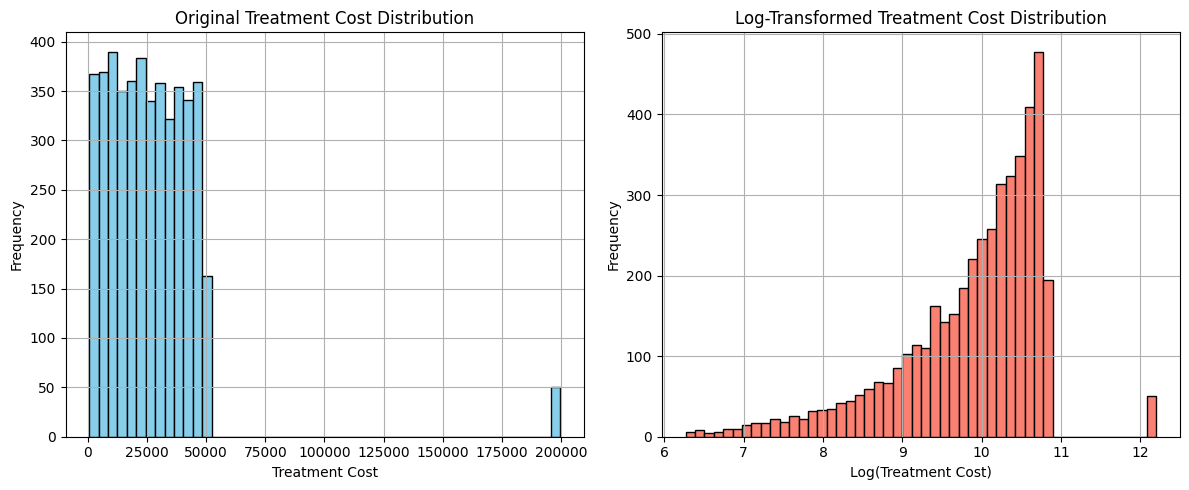

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Apply log transformation (handle zeros/missing safely)
df['Treatment_Cost_Log'] = np.log1p(df['Treatment_Cost'])  # log(1+x) avoids log(0)

# Compare distributions
plt.figure(figsize=(12,5))

# Original distribution
plt.subplot(1,2,1)
df['Treatment_Cost'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title("Original Treatment Cost Distribution")
plt.xlabel("Treatment Cost")
plt.ylabel("Frequency")

# Log-transformed distribution
plt.subplot(1,2,2)
df['Treatment_Cost_Log'].hist(bins=50, color='salmon', edgecolor='black')
plt.title("Log-Transformed Treatment Cost Distribution")
plt.xlabel("Log(Treatment Cost)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


**Q9. Time-Based Missing Handling**

**Scenario:**
 **Admission dates should follow a logical sequence.**

**Task:**

**Sort data by Admission_Date**

**Apply forward fill or backward fill where appropriate**

**Justify your choice**

In [29]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Convert Admission_Date to datetime
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'], errors='coerce', dayfirst=True)

# Sort by Admission_Date
df = df.sort_values(by='Admission_Date')

print(df)

# Applying the chosen method (e.g., Forward Fill)
df['Admission_Date'] = df['Admission_Date'].ffill()
print(df['Admission_Date'])

      Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
2702       17230  41.0    Male  Bangalore  Hypertension               18   
2624       16450  57.0  Female    Chennai      Diabetes               15   
1791       14612  94.0    Male      Delhi  Hypertension               14   
4292       12430  25.0    Male    Chennai      Diabetes               11   
2642       19262   NaN  Female  Hyderabad        Asthma                9   
...          ...   ...     ...        ...           ...              ...   
3456       19171   NaN  Female     Mumbai           Flu                1   
4744       12671  20.0  Female     Mumbai      COVID-19                8   
3013       13630  73.0    Male  Bangalore      Diabetes                3   
5097       19171   NaN  Female     Mumbai           Flu                1   
1723       13432   NaN    Male  Bangalore  Hypertension                9   

      Treatment_Cost  Insurance_Coverage Admission_Date  
2702      12398.0000         

Justification
Forward Fill (ffill): Best when admission records are sequential and missing dates should logically inherit the previous patient’s admission date (common in hospital logs).

Backward Fill (bfill): Useful if missing dates occur at the start of the dataset or when the next available date is more reliable.

### **Choice**: In healthcare datasets, forward fill is usually preferred because patient records are chronological, and missing dates are more likely to be close to the last valid entry.